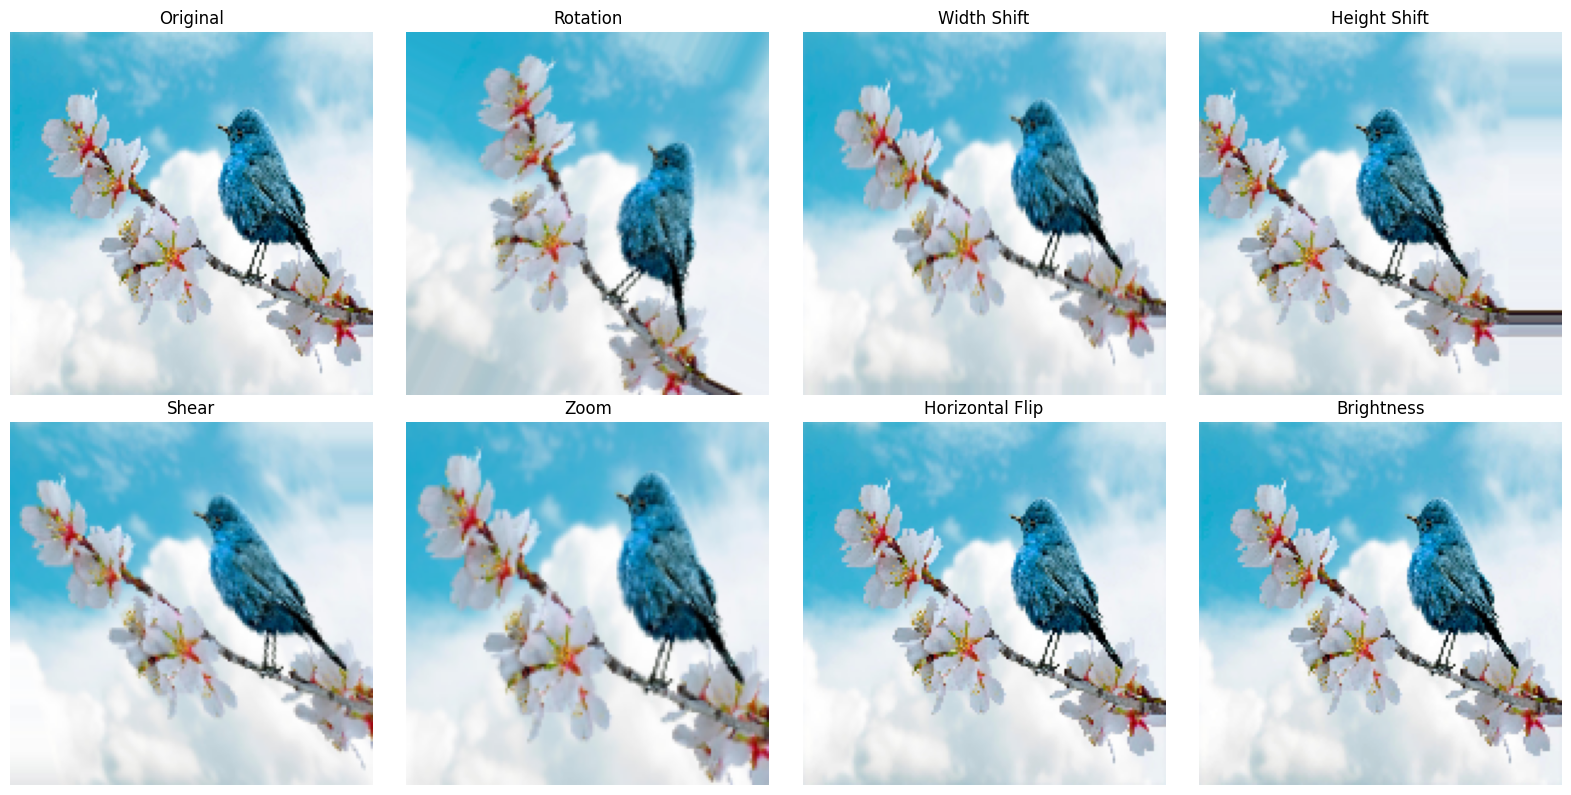

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
import requests
import os

# Download sample image
img_local_path = '/content/bird.jpg'


# Load and prepare image
img = load_img(img_local_path, target_size=(150, 150))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)

# Define transformations
transformations = {
    "Original": ImageDataGenerator(),
    "Rotation": ImageDataGenerator(rotation_range=40),
    "Width Shift": ImageDataGenerator(width_shift_range=0.2),
    "Height Shift": ImageDataGenerator(height_shift_range=0.2),
    "Shear": ImageDataGenerator(shear_range=20),
    "Zoom": ImageDataGenerator(zoom_range=0.5),
    "Horizontal Flip": ImageDataGenerator(horizontal_flip=True),
    "Brightness": ImageDataGenerator(brightness_range=[0.2, 1.5])
}

# Plot the results
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, (name, datagen) in zip(axes, transformations.items()):
    for batch in datagen.flow(x, batch_size=1):
        ax.imshow(array_to_img(batch[0]))
        ax.set_title(name)
        ax.axis('off')
        break

plt.tight_layout()
plt.show()
